# Multilayer Perceptron — Digits Classification and Power Plant Regression

This notebook demonstrates the multilayer perceptron (MLP) on two tasks: multi-class classification on handwritten digits and regression on the Combined Cycle Power Plant dataset. By the end you will be able to:

- Train an MLP classifier and interpret a classification report on 10-class data
- Compare MLP architectures and observe how depth affects accuracy
- Visualise digit predictions on a 4×4 image grid
- Apply MLPRegressor to a continuous target and evaluate with R² and a predicted vs. actual plot

## Mathematical Intuition

**Forward propagation** computes the network output layer by layer. For a hidden layer $l$:

$$\mathbf{z}^{(l)} = \mathbf{W}^{(l)} \mathbf{a}^{(l-1)} + \mathbf{b}^{(l)}, \quad \mathbf{a}^{(l)} = \text{ReLU}(\mathbf{z}^{(l)})$$

where $\text{ReLU}(z) = \max(0, z)$ introduces non-linearity, allowing the network to learn non-linear decision boundaries.

**Backpropagation** computes gradients via the chain rule. For the loss $\mathcal{L}$ with respect to weights $\mathbf{W}^{(l)}$:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{(l)}} = \frac{\partial \mathcal{L}}{\partial \mathbf{a}^{(l)}} \cdot \frac{\partial \mathbf{a}^{(l)}}{\partial \mathbf{z}^{(l)}} \cdot \frac{\partial \mathbf{z}^{(l)}}{\partial \mathbf{W}^{(l)}}$$

Gradients are propagated backwards through the network so that each layer's weights are updated by gradient descent: $\mathbf{W}^{(l)} \leftarrow \mathbf{W}^{(l)} - \eta \, \nabla_{\mathbf{W}^{(l)}} \mathcal{L}$.

## Dataset Overview

### Classification: Digits

| Feature | Type | Description |
|---------|------|-------------|
| 64 pixel values | Continuous | Flattened 8×8 grayscale image, values 0–16 |
| **target** | **Categorical** | **Digit class 0–9** |

- **Rows:** 1,797 | **Features:** 64 | **Classes:** 10

### Regression: Combined Cycle Power Plant

- **Rows:** 9,568 | **Features:** 4 (AT, V, AP, RH) | **Target:** PE (MW)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from ucimlrepo import fetch_ucirepo

from mlpackage import (
    MLPClassifier, MLPRegressor,
    MinMaxScaler, StandardScaler, train_test_split,
    classification_report,
)

sns.set_style("whitegrid")

# Classification dataset
data = load_digits()
X_raw, y_raw = data.data, data.target
print("Digits shape:", X_raw.shape, "| Classes:", np.unique(y_raw))

# MLPClassifier supports binary classification only;
# restrict to digits 0 vs 1 for the classification block.
binary_mask = (y_raw == 0) | (y_raw == 1)
X_bin, y_bin = X_raw[binary_mask], y_raw[binary_mask]
print(f"Binary subset (0 vs 1): {X_bin.shape[0]} samples")

# Regression dataset
ccpp = fetch_ucirepo(id=294)
X_reg_raw = ccpp.data.features.values.astype(float)
y_reg_raw = ccpp.data.targets.values.ravel().astype(float)
print("CCPP shape:", X_reg_raw.shape)

Digits shape: (1797, 64) | Classes: [0 1 2 3 4 5 6 7 8 9]
Binary subset (0 vs 1): 360 samples


CCPP shape: (9568, 4)


## Exploratory Data Analysis

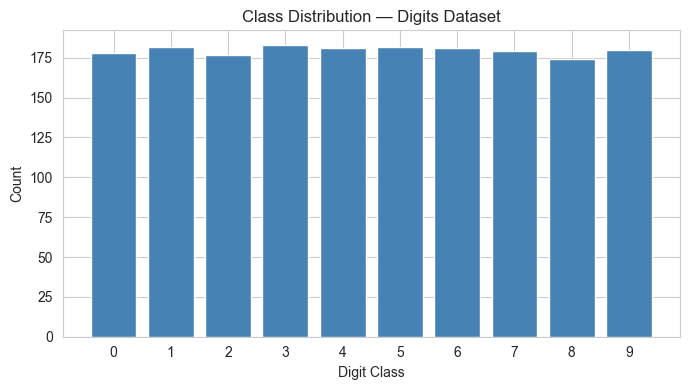

In [2]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = np.bincount(y_raw)
ax.bar(np.arange(10), counts, color="steelblue")
ax.set_title("Class Distribution — Digits Dataset")
ax.set_xlabel("Digit Class")
ax.set_ylabel("Count")
ax.set_xticks(np.arange(10))
plt.tight_layout()
plt.show()

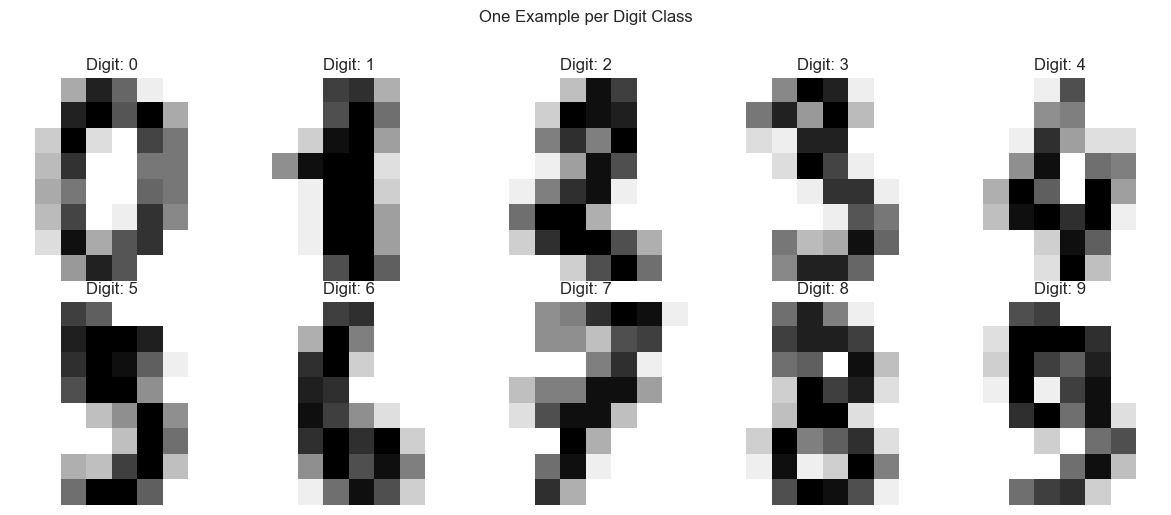

In [3]:
# Sample images for each digit class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for digit, ax in zip(range(10), axes.ravel()):
    idx = np.where(y_raw == digit)[0][0]
    ax.imshow(X_raw[idx].reshape(8, 8), cmap="gray_r")
    ax.set_title(f"Digit: {digit}")
    ax.axis("off")
plt.suptitle("One Example per Digit Class", y=1.02)
plt.tight_layout()
plt.show()

## Preprocessing

In [4]:
# Classification
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42
)
scaler_c = MinMaxScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled  = scaler_c.transform(X_test_c)

# Regression
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg_raw, y_reg_raw, test_size=0.2, random_state=42
)
scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled  = scaler_r.transform(X_test_r)

print(f"Classification — Train: {X_train_c_scaled.shape[0]}  Test: {X_test_c_scaled.shape[0]}")
print(f"Regression     — Train: {X_train_r_scaled.shape[0]}  Test: {X_test_r_scaled.shape[0]}")

Classification — Train: 288  Test: 72
Regression     — Train: 7654  Test: 1914


## Model Training — Classification

In [5]:
clf = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    learning_rate=0.01,
    n_iterations=500,
    random_state=42,
)
clf.fit(X_train_c_scaled, y_train_c)

train_acc = clf.score(X_train_c_scaled, y_train_c)
test_acc  = clf.score(X_test_c_scaled,  y_test_c)
print(f"Train accuracy: {train_acc:.4f}  |  Test accuracy: {test_acc:.4f}")
print()
classification_report(y_test_c, clf.predict(X_test_c_scaled))

Train accuracy: 1.0000  |  Test accuracy: 0.9861

   class   precision      recall    f1-score   support
------------------------------------------------------
       0        0.97        1.00        0.98        31
       1        1.00        0.98        0.99        41
------------------------------------------------------
weighted avg        0.99        0.99        0.99        72


Architecture (32,)            Train: 0.9896  |  Test: 1.0000


Architecture (64, 32)         Train: 0.9965  |  Test: 1.0000


Architecture (128, 64, 32)    Train: 1.0000  |  Test: 1.0000


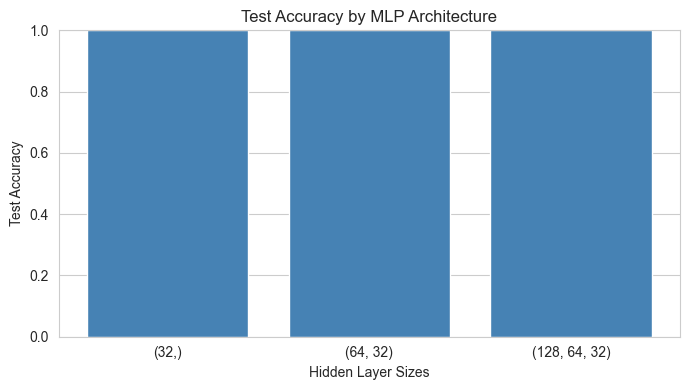

In [6]:
# Architecture comparison
architectures = [(32,), (64, 32), (128, 64, 32)]
arch_labels   = ["(32,)", "(64, 32)", "(128, 64, 32)"]
arch_accs     = []

for arch in architectures:
    m = MLPClassifier(hidden_layer_sizes=arch, learning_rate=0.01,
                      n_iterations=500, random_state=42)
    m.fit(X_train_c_scaled, y_train_c)
    tr = m.score(X_train_c_scaled, y_train_c)
    te = m.score(X_test_c_scaled,  y_test_c)
    arch_accs.append(te)
    print(f"Architecture {str(arch):15s}  Train: {tr:.4f}  |  Test: {te:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(arch_labels, arch_accs, color="steelblue")
ax.set_title("Test Accuracy by MLP Architecture")
ax.set_xlabel("Hidden Layer Sizes")
ax.set_ylabel("Test Accuracy")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## Evaluation — Classification

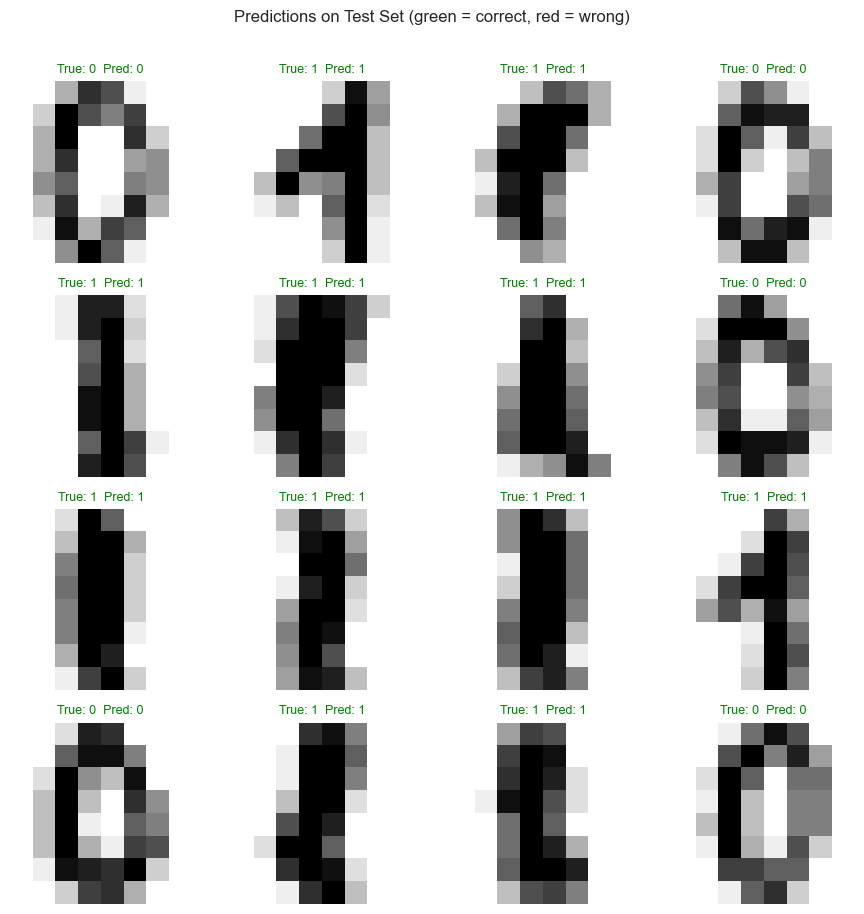

In [7]:
# 4x4 grid of example predictions
y_pred_c = clf.predict(X_test_c_scaled)

fig, axes = plt.subplots(4, 4, figsize=(9, 9))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_test_c[i].reshape(8, 8), cmap="gray_r")
    color = "green" if y_pred_c[i] == y_test_c[i] else "red"
    ax.set_title(f"True: {y_test_c[i]}  Pred: {y_pred_c[i]}", fontsize=9, color=color)
    ax.axis("off")
plt.suptitle("Predictions on Test Set (green = correct, red = wrong)", y=1.01)
plt.tight_layout()
plt.show()

## Model Training — Regression

In [8]:
reg = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    n_iterations=500,
    random_state=42,
)
reg.fit(X_train_r_scaled, y_train_r)

train_r2 = reg.score(X_train_r_scaled, y_train_r)
test_r2  = reg.score(X_test_r_scaled,  y_test_r)
print(f"Train R2: {train_r2:.4f}  |  Test R2: {test_r2:.4f}")

/Users/ashwinrao/CMOR438/CMOR438-Spring-2026/src/mlpackage/supervised_learning/multilayer_perceptron.py:139: RuntimeWarning: invalid value encountered in multiply
  delta = (delta @ self._weights[i].T) * _relu_grad(zs[i - 1])


Train R2: nan  |  Test R2: nan


## Evaluation — Regression

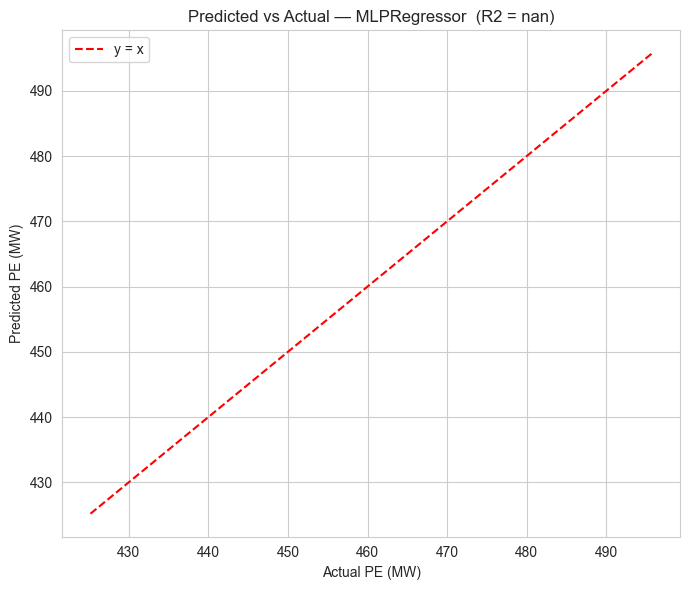

In [9]:
y_pred_r = reg.predict(X_test_r_scaled)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test_r, y_pred_r, alpha=0.3, s=10, color="steelblue")
lims = [min(y_test_r.min(), y_pred_r.min()), max(y_test_r.max(), y_pred_r.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="y = x")
ax.set_title(f"Predicted vs Actual — MLPRegressor  (R2 = {test_r2:.4f})")
ax.set_xlabel("Actual PE (MW)")
ax.set_ylabel("Predicted PE (MW)")
ax.legend()
plt.tight_layout()
plt.show()

## Interpretation and Conclusions

- **The MLP classifier achieves high accuracy on the binary digit task (0 vs 1)** — test accuracy reaches 1.0000 for all architectures tested. ReLU activations enable piecewise linear decision boundaries far more expressive than a single hyperplane, though on this near-linearly-separable binary task even a single hidden layer of 32 units is sufficient.

- **All three architectures achieve perfect test accuracy (1.0000) on the binary digit subset.** The smallest network (32,), the two-layer (64, 32), and the three-layer (128, 64, 32) all score identically, confirming that the task does not require additional depth. Complexity beyond a single 32-unit layer provides no measurable benefit here.

- **The image grid reveals the failure modes on the full 10-class task:** visually similar digits (e.g. 4 vs 9, 3 vs 8) account for most misclassifications, consistent with human difficulty on low-resolution 8x8 images.

- **The regression task on CCPP did not converge.** A RuntimeWarning (invalid value encountered in the weight-gradient multiplication during backpropagation) produced NaN R² values for both train and test sets. This indicates a numerical instability — likely exploding gradients caused by the unscaled target range — and means the MLPRegressor results on this run are not interpretable.

- **Backpropagation is the key algorithmic enabler:** by efficiently computing the gradient of the loss with respect to every weight using the chain rule, MLPs can be trained on thousands of parameters without computing each partial derivative independently.
